# Visualize the features

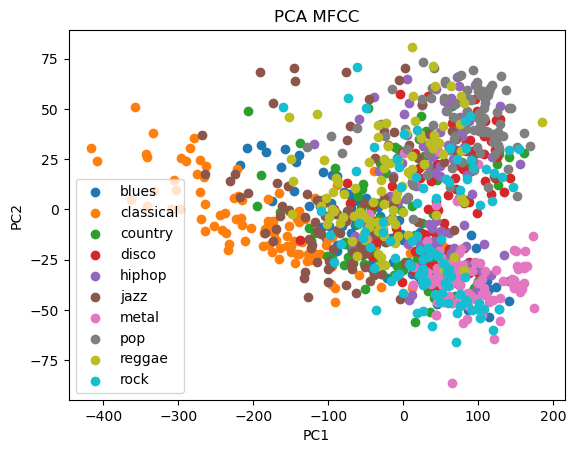

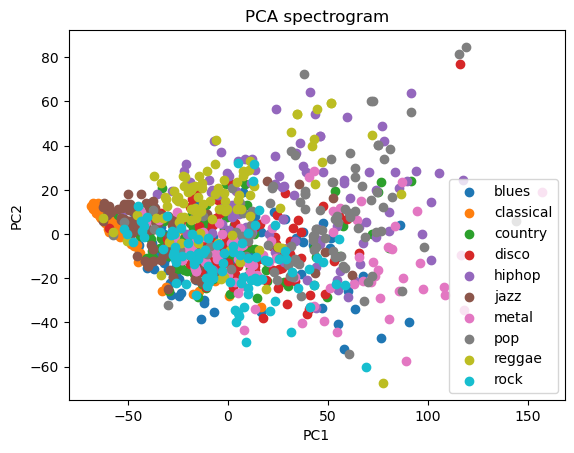

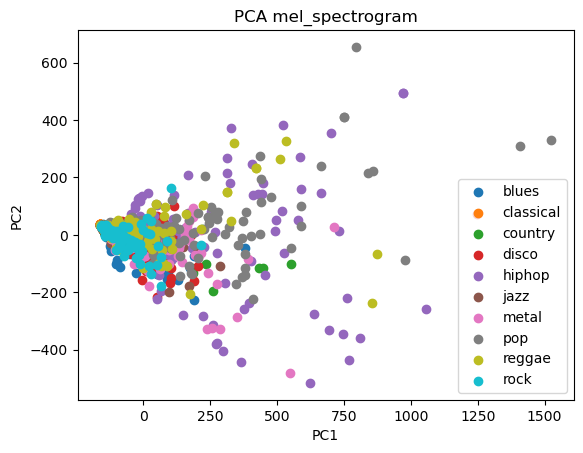

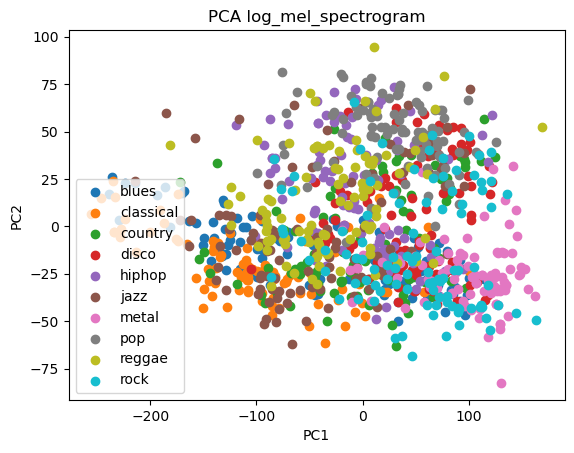

In [9]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from pathlib import Path

FEATURES_JSON = Path("features/manual_features.json")
FEATURES = ["MFCC", "spectrogram", "mel_spectrogram", "log_mel_spectrogram"]

with open(FEATURES_JSON) as f:
    data = json.load(f)

genres = sorted({v["genre"] for v in data.values()})
filenames = list(data.keys())
labels = [data[f]["genre"] for f in filenames]

for feature in FEATURES:
    X = [data[f][feature] for f in filenames]
    pc = PCA(n_components=2).fit_transform(X)

    plt.figure()
    for g in genres:
        mask = [l == g for l in labels]
        pc1_points = pc[mask, 0]
        pc2_points = pc[mask, 1]
        plt.scatter(pc1_points, pc2_points, label=g)

    plt.title(f"PCA {feature}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.show()
